# Train ML Models for modelling the competitors' prices

This notebook train the ML models in order to create the constraints for the optimization problem. The models are trained using the data generated in the DataGenerationROBIN module.

In [107]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [108]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Allow pandas to display all columns
pd.set_option("display.max_columns", None)

In [109]:
def smape(y_true, y_pred, epsilon=1e-8):
    """
    Calcula el Symmetric Mean Absolute Percentage Error (sMAPE)
    entre los valores reales y predichos.

    Parámetros:
    - y_true: array-like, valores reales
    - y_pred: array-like, valores predichos
    - epsilon: valor pequeño para evitar divisiones por cero

    Retorna:
    - smape: float, error porcentual simétrico medio
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape = np.mean(np.abs(y_pred - y_true) / (denominator + epsilon)) * 100
    return smape


## Load the dataset and preprocess it

In [110]:
path_data = "../DataGenerationROBIN/data/MAD-BCN/aggregated/MAD-BCN_2025.csv"

data = pd.read_csv(path_data, sep=",")

y_col = "price"  # The price of the service
y = data[y_col]
X = data.drop(columns=[y_col], axis=1, inplace=False)
X_processed = X.copy()

data.columns

Index(['service_id', 'train_type', 'capacity', 'train_model', 'year', 'month',
       'day_of_week', 'departure_time', 'duration', 'price', 'passengers',
       'time_distance_competitor_-2', 'price_competitor_-2',
       'train_type_competitor_-2', 'duration_competitor_-2',
       'time_distance_competitor_-1', 'price_competitor_-1',
       'train_type_competitor_-1', 'duration_competitor_-1',
       'time_distance_competitor_1', 'price_competitor_1',
       'train_type_competitor_1', 'duration_competitor_1',
       'time_distance_competitor_2', 'price_competitor_2',
       'train_type_competitor_2', 'duration_competitor_2'],
      dtype='object')

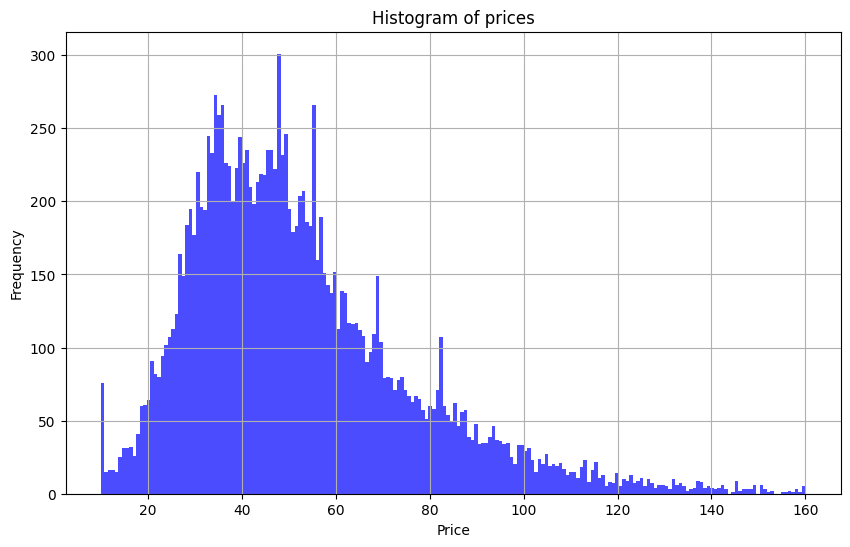

In [111]:
# Plot the histogram of prices
plt.figure(figsize=(10, 6))
plt.hist(y, bins=200, color="blue", alpha=0.7)
plt.title("Histogram of prices")
plt.xlabel("Price") 
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [112]:
## Process temporal features

# Create new column 'weekend' based on 'day_of_week'
#X_processed["weekend"] = (X_processed["day_of_week"] >= 5).astype(int)


# Apply sine/cosine transformation to the columns: 'month', 'day_of_week', 'departure_time'
def sine_cosine_transform(df, col, period, drop=False):
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)
    if drop:
        df.drop(columns=[col], inplace=True)
    return df


X_processed = sine_cosine_transform(X_processed, "day_of_week", 7, drop=True)


In [113]:
## Process categorical features

# Apply one-hot encoding to the columns: 'train_type' and train_type_competitor_i
cols_to_encode = ["train_type"] #+ [
#    f"train_type_competitor_{i}" for i in range(-2, 3) if i != 0
#]

# Use pandas get_dummies to one-hot encode the specified columns
#X_processed = pd.get_dummies(
#    X_processed, columns=cols_to_encode, drop_first=False, dtype=int
#)

In [114]:
## Remove unused columns
X_processed.drop(
    columns=['service_id', 'capacity', 'train_model', 'year', 'month', #'day_of_week'
        'departure_time', 'passengers'] + [
        f"duration_competitor_{i}" for i in range(-2, 3) if i != 0
        ] + [
        f"train_type_competitor_{i}" for i in range(-2, 3) if i != 0
        ],
    inplace=True
)
print(X_processed.columns)

Index(['train_type', 'duration', 'time_distance_competitor_-2',
       'price_competitor_-2', 'time_distance_competitor_-1',
       'price_competitor_-1', 'time_distance_competitor_1',
       'price_competitor_1', 'time_distance_competitor_2',
       'price_competitor_2', 'day_of_week_sin', 'day_of_week_cos'],
      dtype='object')


In [115]:
# Filter prices on only one company
mask = X_processed["train_type"] == "OUIGO"
X_processed = X_processed[mask].copy()
y = y[mask].copy()


X_processed.drop(
    columns=["train_type"], inplace=True,
)

In [117]:
## Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=2026, shuffle=False)

#X_train = X_processed.copy()
#X_test = X_processed.copy()
#y_train = y.copy()
#y_test = y.copy()

print(f"Number of training samples: {len(X_train)}, Number of testing samples: {len(X_test)}")

Number of training samples: 1240, Number of testing samples: 532


In [118]:
## Scale the features

scaled_feat = (
    ["duration"]
    #+ [f"duration_competitor_{i}" for i in range(-2, 3) if i != 0]
    #+ [f"time_distance_competitor_{i}" for i in range(-2, 3) if i != 0]
    + [f"price_competitor_{i}" for i in range(-2, 3) if i != 0]
)

# Scale the features
feat_scaler = StandardScaler()
X_train[scaled_feat] = feat_scaler.fit_transform(X_train[scaled_feat])
X_test[scaled_feat] = feat_scaler.transform(X_test[scaled_feat])

# Scale the target variable
target_scaler = StandardScaler()
y_train = pd.DataFrame(target_scaler.fit_transform(y_train.values.reshape(-1, 1)), columns = [y.name])
y_test = pd.DataFrame(target_scaler.transform(y_test.values.reshape(-1, 1)), columns = [y.name])


In [119]:
## Describe the training data
X_train.describe()

,duration,time_distance_competitor_-2,price_competitor_-2,time_distance_competitor_-1,price_competitor_-1,time_distance_competitor_1,price_competitor_1,time_distance_competitor_2,price_competitor_2,day_of_week_sin,day_of_week_cos
count,1.240000e+03,1240.000000,1.240000e+03,1240.000000,1.240000e+03,1240.000000,1.240000e+03,1240.000000,1.240000e+03,1240.000000,1240.000000
mean,-9.812939e-17,-88.326774,-1.812170e-16,-18.615968,8.738530e-17,40.370323,5.300420e-17,215.373387,-3.130113e-16,-0.010588,0.018362
std,1.000403e+00,189.225123,1.000403e+00,14.028399,1.000403e+00,144.593020,1.000403e+00,338.869985,1.000403e+00,0.713884,0.700519
min,-1.175579e+00,-845.400000,-1.967544e+00,-54.000000,-1.598066e+00,5.400000,-1.733993e+00,10.200000,-1.890921e+00,-0.974928,-0.900969
25%,-1.175579e+00,-39.600000,-7.697641e-01,-34.800000,-7.310780e-01,5.400000,-7.203693e-01,25.200000,-7.784735e-01,-0.781831,-0.900969
50%,3.790439e-01,-39.600000,-1.184859e-01,-10.200000,-2.344949e-01,15.000000,-2.086410e-01,65.400000,-1.915822e-01,0.000000,-0.222521
75%,3.790439e-01,-34.800000,7.529621e-01,-4.800000,5.563146e-01,25.200000,4.015213e-01,80.400000,6.404105e-01,0.781831,0.623490
max,1.415460e+00,-15.000000,3.004049e+00,-4.800000,3.279961e+00,874.800000,4.051059e+00,889.800000,3.819731e+00,0.974928,1.000000


## Train a Regression model

In [120]:
#model = LinearRegression()

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=2026,
    n_jobs=-1
)

# Fit the model
model.fit(X_train, y_train)

/Users/joseangel/miniforge3/envs/dcl-trainmarket/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_jobs=-1, random_state=2026)

In [121]:
y_pred_test = model.predict(X_test)

y_pred_test = np.array(y_pred_test).flatten()
y_true_test = y_test.values.flatten()

# Inverse transform the predictions and the true values
y_pred_test = y_pred_test * target_scaler.scale_[0] + target_scaler.mean_[0]
y_true_test = y_true_test * target_scaler.scale_[0] + target_scaler.mean_[0]

## Evaluate the model

In [122]:
# Evaluate the model
mape = mean_absolute_percentage_error(y_true_test, y_pred_test)
mse = mean_squared_error(y_true_test, y_pred_test)
r2 = r2_score(y_true_test, y_pred_test)
smape_value = smape(y_true_test, y_pred_test)
print(f"MAPE: {mape:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R2: {r2:.4f}")
print(f"sMAPE: {smape_value:.4f}")

MAPE: 0.2755
MSE: 101.0499
R2: 0.5147
sMAPE: 22.8234


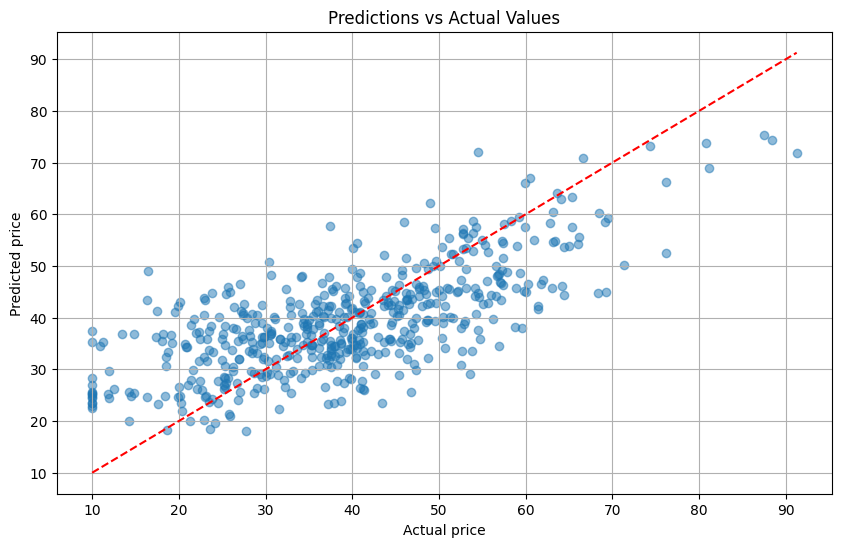

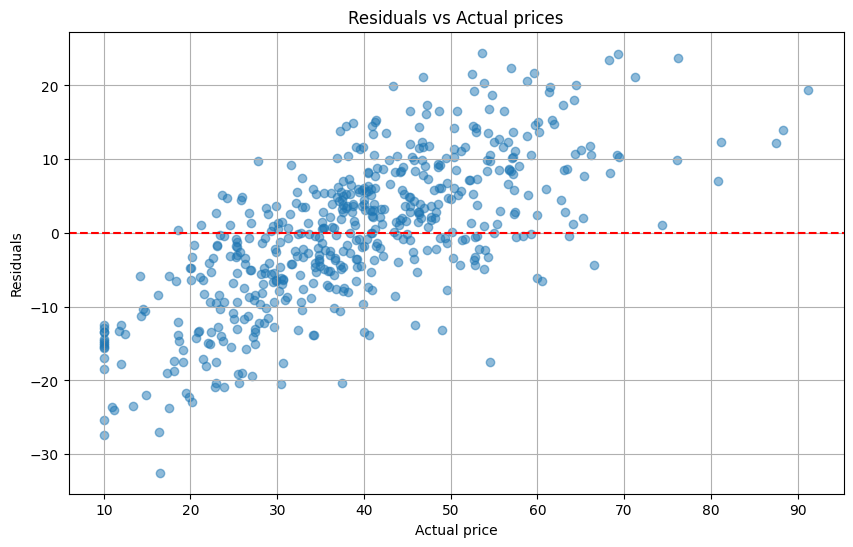

In [123]:
# Plot the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_true_test, y_pred_test, alpha=0.5)
plt.plot([y_true_test.min(), y_true_test.max()], [y_true_test.min(), y_true_test.max()], color='red', linestyle='--')
plt.title("Predictions vs Actual Values")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.grid()
plt.show()

# Plot the residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_true_test, y_true_test - y_pred_test, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Actual prices")
plt.xlabel("Actual price")
plt.ylabel("Residuals")
plt.grid()
plt.show()

In [124]:
# Count number of instances at a distance < d of the real value
def count_within_distance(y_true, y_pred, distance):
    n_instances = np.sum(np.abs(y_pred - y_true) < distance)
    percentage = np.round((n_instances / len(y_true)) * 100, 2)
    return n_instances, percentage

print(f"Percentage of instances with prediction within 5 euros of the real value: {count_within_distance(y_true_test, y_pred_test, 5)[1]}")
print(f"Percentage of instances with prediction within 10 euros of the real value: {count_within_distance(y_true_test, y_pred_test, 10)[1]}")
print(f"Percentage of instances with prediction within 20 euros of the real value: {count_within_distance(y_true_test, y_pred_test, 20)[1]}")


Percentage of instances with prediction within 5 euros of the real value: 40.23
Percentage of instances with prediction within 10 euros of the real value: 67.48
Percentage of instances with prediction within 20 euros of the real value: 94.36


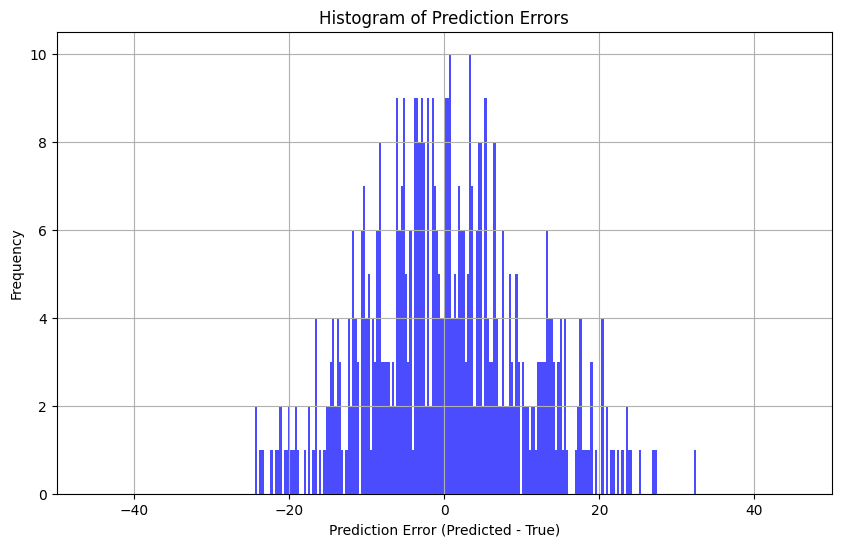

In [125]:
# Histogram of the errors
plt.figure(figsize=(10, 6))
plt.hist(
    np.array(y_pred_test) - np.array(y_true_test), bins=200, color="blue", alpha=0.7
)
plt.xlim(-50, 50)
plt.title("Histogram of Prediction Errors")
plt.xlabel("Prediction Error (Predicted - True)")
plt.ylabel("Frequency")
plt.grid()
plt.show()